In [2]:
import numpy as np
import pandas as pd


In [3]:
df=pd.read_csv('water_potability.csv')
df.head(5)

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [5]:
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

In [8]:
df["ph"].fillna(value = df["ph"].mean(), inplace = True)
df["Sulfate"].fillna(value = df["Sulfate"].mean(), inplace = True)
df["Trihalomethanes"].fillna(value = df["Trihalomethanes"].mean(), inplace = True)

C:\Users\GEET MANTRI\AppData\Local\Temp\ipykernel_29428\3893884686.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["ph"].fillna(value = df["ph"].mean(), inplace = True)
C:\Users\GEET MANTRI\AppData\Local\Temp\ipykernel_29428\3893884686.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves

In [9]:
df.isnull().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

In [10]:
#EDA starts
import seaborn as sns
import matplotlib.pyplot as plt

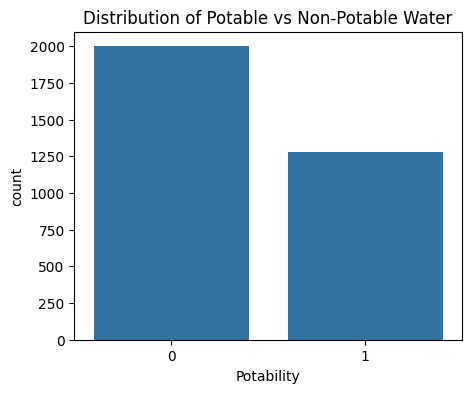

In [11]:
# TARGET VARIABLE DISTRIBUTION
# ------------------------------------------
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='Potability')
plt.title("Distribution of Potable vs Non-Potable Water")
plt.show()

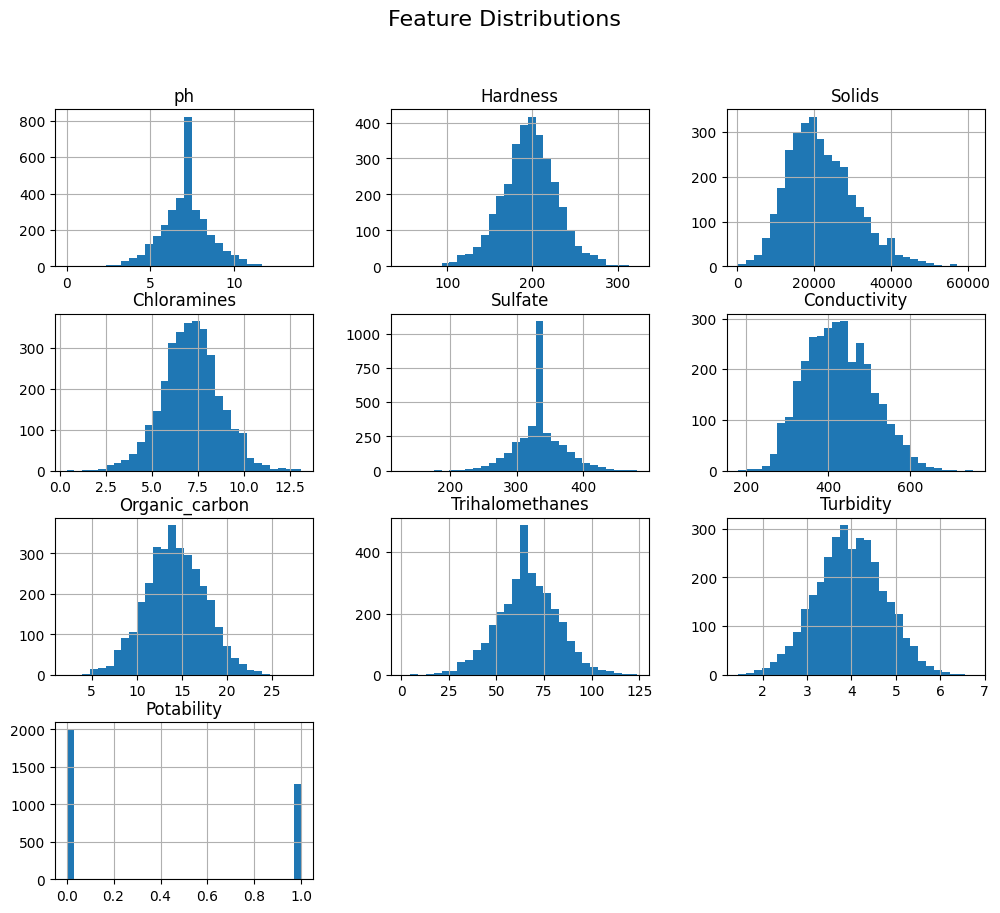

In [12]:
df.hist(figsize=(12,10), bins=30)
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

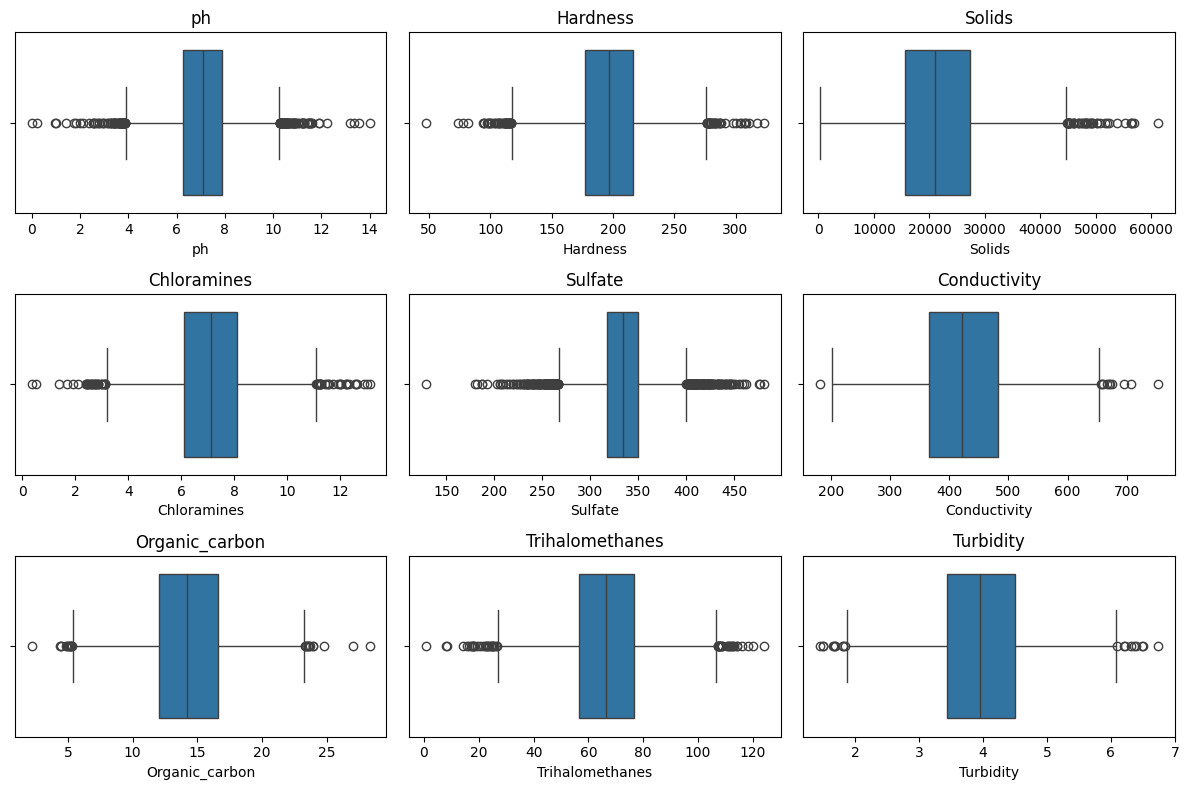

In [13]:
plt.figure(figsize=(12,8))
for i, col in enumerate(df.columns[:-1], 1):
    plt.subplot(3,3,i)
    sns.boxplot(x=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [14]:
#  CORRELATION MATRIX
# ------------------------------------------
corr = df.corr()

print("\nCorrelation Matrix:")
print(corr)


Correlation Matrix:
                       ph  Hardness    Solids  Chloramines   Sulfate  \
ph               1.000000  0.075833 -0.081884    -0.031811  0.014403   
Hardness         0.075833  1.000000 -0.046899    -0.030054 -0.092766   
Solids          -0.081884 -0.046899  1.000000    -0.070148 -0.149840   
Chloramines     -0.031811 -0.030054 -0.070148     1.000000  0.023791   
Sulfate          0.014403 -0.092766 -0.149840     0.023791  1.000000   
Conductivity     0.017192 -0.023915  0.013831    -0.020486 -0.014059   
Organic_carbon   0.040061  0.003610  0.010242    -0.012653  0.026909   
Trihalomethanes  0.002994 -0.012690 -0.008875     0.016627 -0.025605   
Turbidity       -0.036222 -0.014449  0.019546     0.002363 -0.009790   
Potability      -0.003287 -0.013837  0.033743     0.023779 -0.020619   

                 Conductivity  Organic_carbon  Trihalomethanes  Turbidity  \
ph                   0.017192        0.040061         0.002994  -0.036222   
Hardness            -0.023915   

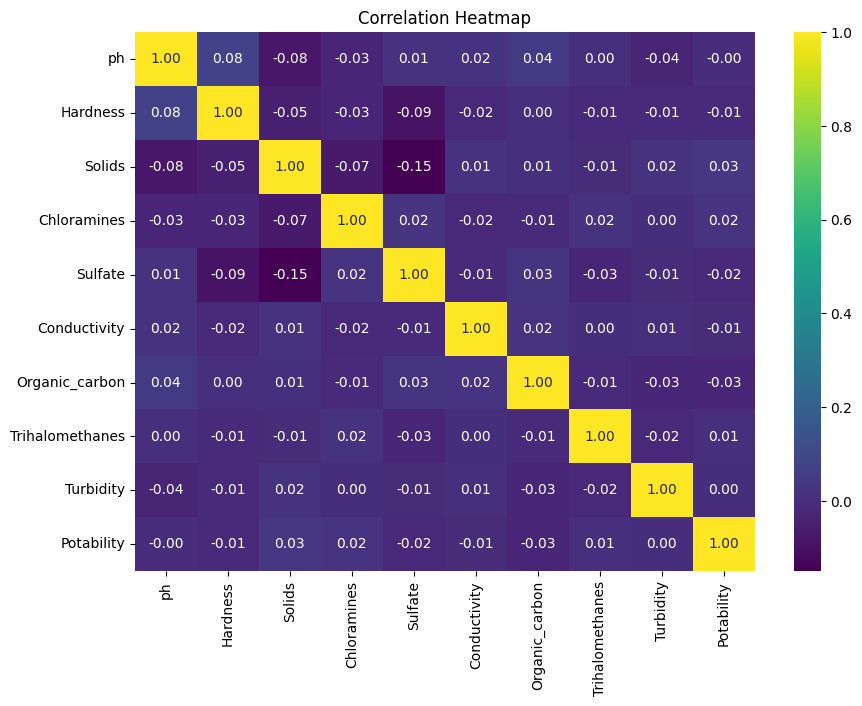

In [15]:
#  CORRELATION HEATMAP
# ------------------------------------------
plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, cmap='viridis', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

In [16]:
from sklearn.model_selection import train_test_split

X = df.drop('Potability', axis=1)   # features
y = df['Potability']                # labels

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(2620, 9) (2620,)
(656, 9) (656,)


In [18]:
#Normalize
from sklearn.preprocessing import MinMaxScaler

In [19]:
scaler = MinMaxScaler()

# Fit on training data only — very important!
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nNormalization complete.")
print("Training scaled sample:", X_train_scaled[:2])


Normalization complete.
Training scaled sample: [[0.47311525 0.51891596 0.27171856 0.44599616 0.51906359 0.40002789
  0.48238685 0.49079027 0.27120552]
 [0.47747855 0.4821049  0.55255029 0.74556353 0.6122632  0.55359856
  0.18584249 0.50493346 0.4838104 ]]


In [20]:
#Model training and evaluation
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, confusion_matrix, roc_curve, auc
)

In [21]:
# ----------------------------------------------------
# MODEL – RANDOM FOREST
# ----------------------------------------------------
model = RandomForestClassifier(random_state=42)
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]

# ----------------------------------------------------
# METRICS
# ----------------------------------------------------
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Accuracy : 0.6784
Precision: 0.6093
Recall   : 0.377
F1 Score : 0.4658


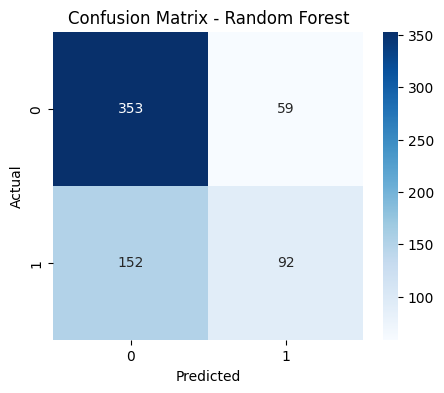

In [22]:
# ----------------------------------------------------
# CONFUSION MATRIX PLOT
# ----------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

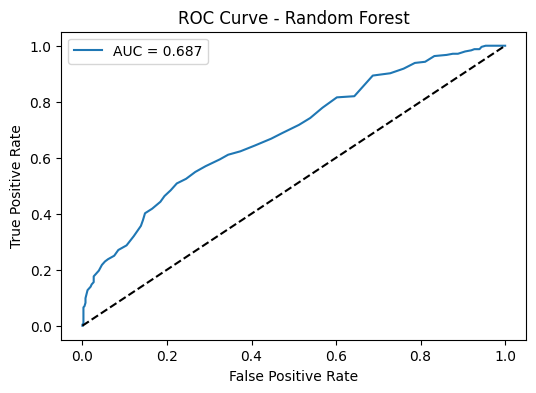

In [23]:
# ----------------------------------------------------
# ROC CURVE
# ----------------------------------------------------
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [24]:
import numpy as np

# Dummy sample (example values)
dummy_data = np.array([[7.2,     # pH
                        150.0,   # Hardness
                        5000.0,  # Solids
                        7.5,     # Chloramines
                        300.0,   # Sulfate
                        450.0,   # Conductivity
                        12.0,    # Organic_carbon
                        80.0,    # Trihalomethanes
                        3.0]])   # Turbidity

# Scale dummy input
dummy_scaled = scaler.transform(dummy_data)

# Predict
prediction = model.predict(dummy_scaled)
prob = model.predict_proba(dummy_scaled)[0][1]

print("Predicted Class:", prediction[0])
print("Probability of being Potable:", round(prob, 4))

Predicted Class: 0
Probability of being Potable: 0.4


c:\Users\GEET MANTRI\anaconda3\envs\water\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


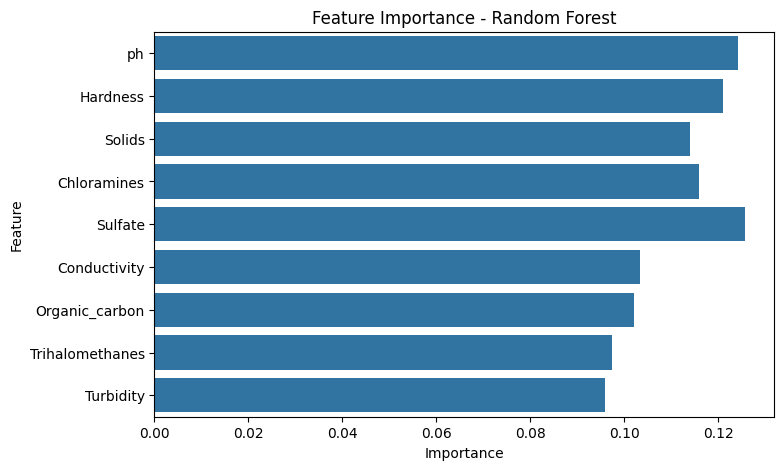

In [25]:
importances = model.feature_importances_
features = X.columns

plt.figure(figsize=(8,5))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

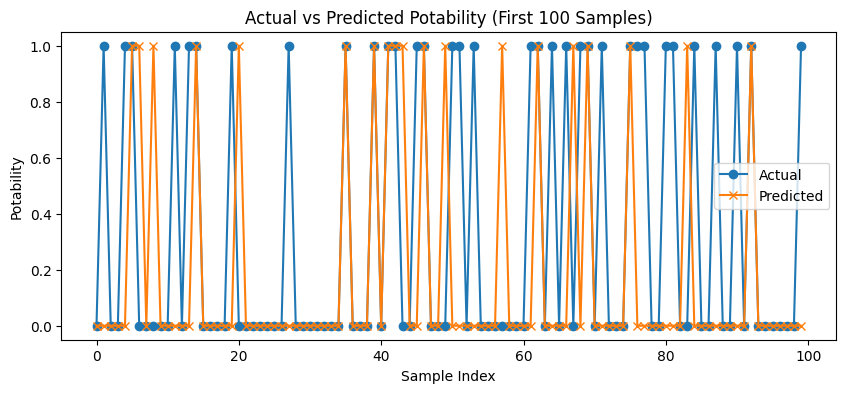

In [26]:
plt.figure(figsize=(10,4))
plt.plot(y_test.values[:100], label="Actual", marker='o')
plt.plot(y_pred[:100], label="Predicted", marker='x')
plt.title("Actual vs Predicted Potability (First 100 Samples)")
plt.xlabel("Sample Index")
plt.ylabel("Potability")
plt.legend()
plt.show()


In [27]:
#Decisiontree
from sklearn.tree import DecisionTreeClassifier

In [28]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]

# ----------------------------------------------------
# METRICS
# ----------------------------------------------------
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Accuracy : 0.5777
Precision: 0.4413
Recall   : 0.5082
F1 Score : 0.4724


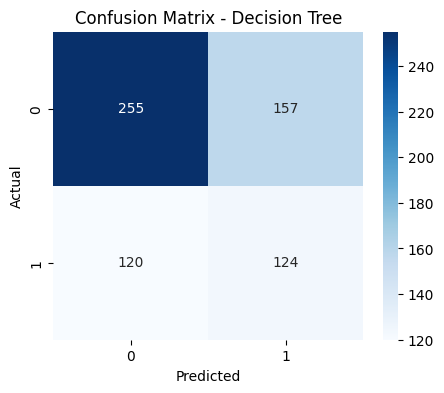

In [29]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

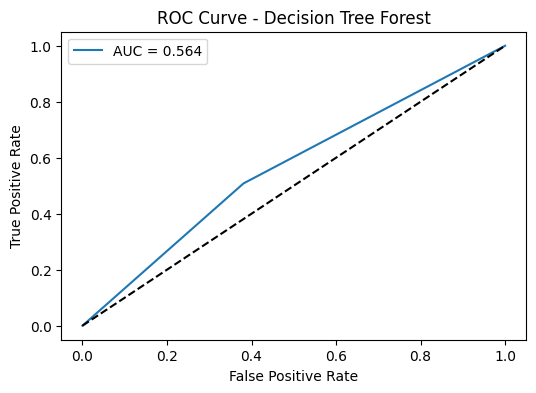

In [30]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.title("ROC Curve - Decision Tree Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [31]:
from sklearn.model_selection import StratifiedKFold

In [32]:
model = RandomForestClassifier(random_state=42)


X = df.drop("Potability", axis=1).values
y = df["Potability"].values

# K-Fold setup
k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

accuracy_list = []
precision_list = []
recall_list = []
f1_list = []

fold_no = 1

for train_index, test_index in skf.split(X, y):
    
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Scaling inside each fold
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Train model
    model.fit(X_train_scaled, y_train)
    
    # Predictions
    y_pred = model.predict(X_test_scaled)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    
    accuracy_list.append(acc)
    precision_list.append(pre)
    recall_list.append(rec)
    f1_list.append(f1)
    
    print(f"\n===== Fold {fold_no} =====")
    print('Train Test Split', (len(X_train)/len(X))*100, ':', (len(X_test)/len(X))*100 )
    print('X_train:',X_train.shape,' y_train:', y_train.shape)
    print('X_test:',X_test.shape,' y_test:', y_test.shape)
    print("Accuracy :", round(acc, 4))
    print("Precision:", round(pre, 4))
    print("Recall   :", round(rec, 4))
    print("F1 Score :", round(f1, 4))
    
    fold_no += 1

# ----------------------------------------------------
# FINAL AVERAGE METRICS
# ----------------------------------------------------
print("\n\n=========== FINAL RESULTS (MEAN ± STD) ===========")
print(f"Accuracy : {np.mean(accuracy_list):.4f} ± {np.std(accuracy_list):.4f}")
print(f"Precision: {np.mean(precision_list):.4f} ± {np.std(precision_list):.4f}")
print(f"Recall   : {np.mean(recall_list):.4f} ± {np.std(recall_list):.4f}")
print(f"F1 Score : {np.mean(f1_list):.4f} ± {np.std(f1_list):.4f}")


===== Fold 1 =====
Train Test Split 79.97557997557998 : 20.024420024420024
X_train: (2620, 9)  y_train: (2620,)
X_test: (656, 9)  y_test: (656,)
Accuracy : 0.6799
Precision: 0.6554
Recall   : 0.3789
F1 Score : 0.4802

===== Fold 2 =====
Train Test Split 80.00610500610502 : 19.993894993894994
X_train: (2621, 9)  y_train: (2621,)
X_test: (655, 9)  y_test: (655,)
Accuracy : 0.6824
Precision: 0.6911
Recall   : 0.3333
F1 Score : 0.4497

===== Fold 3 =====
Train Test Split 80.00610500610502 : 19.993894993894994
X_train: (2621, 9)  y_train: (2621,)
X_test: (655, 9)  y_test: (655,)
Accuracy : 0.6595
Precision: 0.6159
Recall   : 0.3333
F1 Score : 0.4326

===== Fold 4 =====
Train Test Split 80.00610500610502 : 19.993894993894994
X_train: (2621, 9)  y_train: (2621,)
X_test: (655, 9)  y_test: (655,)
Accuracy : 0.6672
Precision: 0.6583
Recall   : 0.3086
F1 Score : 0.4202

===== Fold 5 =====
Train Test Split 80.00610500610502 : 19.993894993894994
X_train: (2621, 9)  y_train: (2621,)
X_test: (655, 9

In [33]:
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

# Split features and target
X = df.drop("Potability", axis=1).values
y = df["Potability"].values

# Normalization
scaler = StandardScaler()
X = scaler.fit_transform(X)

# ---------------------------
# K-Fold Setup
# ---------------------------
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# To store metrics
acc_list, pre_list, rec_list, f1_list = [], [], [], []

fold = 1

# ---------------------------
# Training Loop
# ---------------------------
for train_idx, test_idx in kf.split(X):

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Print Split Percent
    train_pct = len(train_idx) / len(df) * 100
    test_pct = len(test_idx) / len(df) * 100

    print(f"\nFold {fold}:")
    print(f"  Train Size: {len(train_idx)} ({train_pct:.2f}%)")
    print(f"  Test Size:  {len(test_idx)} ({test_pct:.2f}%)")

    # Model (change this to any algorithm you want)
    model = RandomForestClassifier()

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
    print(f"F1-score:  {f1_score(y_test, y_pred):.4f}")
    
    # Metrics
    acc_list.append(accuracy_score(y_test, y_pred))
    pre_list.append(precision_score(y_test, y_pred))
    rec_list.append(recall_score(y_test, y_pred))
    f1_list.append(f1_score(y_test, y_pred))

    fold += 1

# ---------------------------
# Final Scores
# ---------------------------
print("\n==============================================")
print("K-Fold Cross Validation Results (Average)")
print("==============================================")
print(f"Accuracy:  {np.mean(acc_list):.4f}")
print(f"Precision: {np.mean(pre_list):.4f}")
print(f"Recall:    {np.mean(rec_list):.4f}")
print(f"F1 Score:  {np.mean(f1_list):.4f}")
print("==============================================")


Fold 1:
  Train Size: 2620 (79.98%)
  Test Size:  656 (20.02%)
Accuracy:  0.6738
Precision: 0.6119
Recall:    0.3361
F1-score:  0.4339

Fold 2:
  Train Size: 2621 (80.01%)
  Test Size:  655 (19.99%)
Accuracy:  0.6779
Precision: 0.6462
Recall:    0.3373
F1-score:  0.4433

Fold 3:
  Train Size: 2621 (80.01%)
  Test Size:  655 (19.99%)
Accuracy:  0.6626
Precision: 0.6797
Recall:    0.3258
F1-score:  0.4405

Fold 4:
  Train Size: 2621 (80.01%)
  Test Size:  655 (19.99%)
Accuracy:  0.6519
Precision: 0.5802
Recall:    0.3052
F1-score:  0.4000

Fold 5:
  Train Size: 2621 (80.01%)
  Test Size:  655 (19.99%)
Accuracy:  0.6901
Precision: 0.7089
Recall:    0.4164
F1-score:  0.5246

K-Fold Cross Validation Results (Average)
Accuracy:  0.6712
Precision: 0.6454
Recall:    0.3442
F1 Score:  0.4484



===== Logistic Regression =====
Accuracy : 0.5908
Precision: 1.0
Recall   : 0.0037
F1 Score : 0.0074


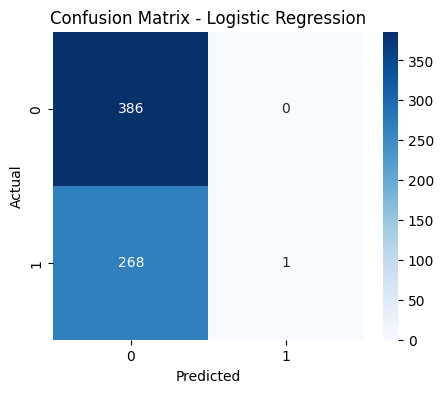


===== KNN =====
Accuracy : 0.6076
Precision: 0.5337
Recall   : 0.3532
F1 Score : 0.4251


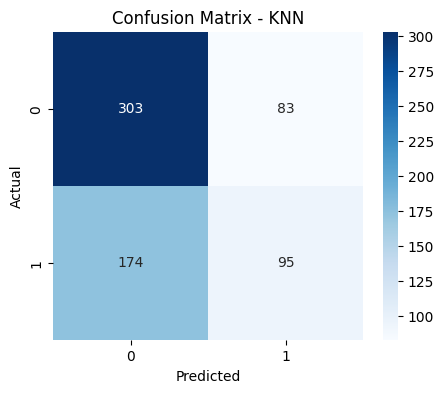


===== SVM (RBF) =====
Accuracy : 0.6244
Precision: 0.6575
Recall   : 0.1784
F1 Score : 0.2807


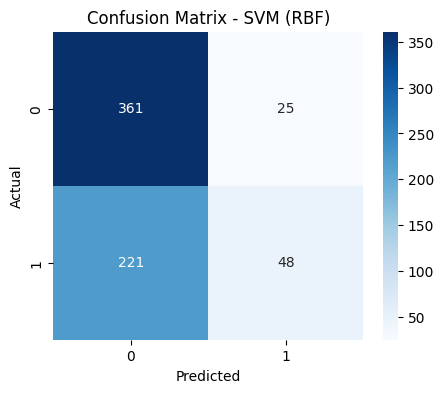


===== Decision Tree =====
Accuracy : 0.5771
Precision: 0.4846
Recall   : 0.4684
F1 Score : 0.4764


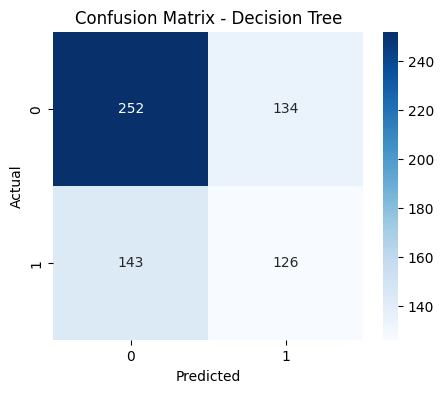


===== Random Forest =====
Accuracy : 0.6275
Precision: 0.605
Recall   : 0.2677
F1 Score : 0.3711


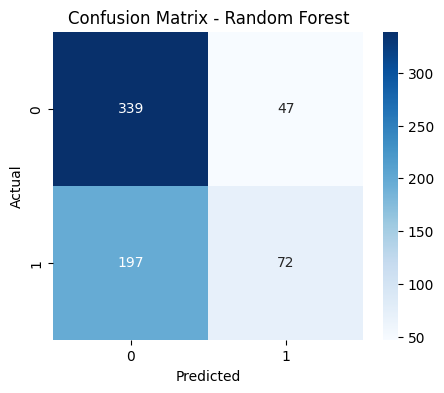


===== Gradient Boosting =====
Accuracy : 0.6198
Precision: 0.625
Recall   : 0.1859
F1 Score : 0.2865


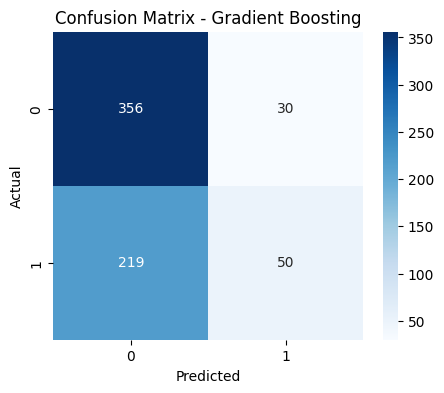


===== AdaBoost =====
Accuracy : 0.5832
Precision: 0.4
Recall   : 0.0297
F1 Score : 0.0554


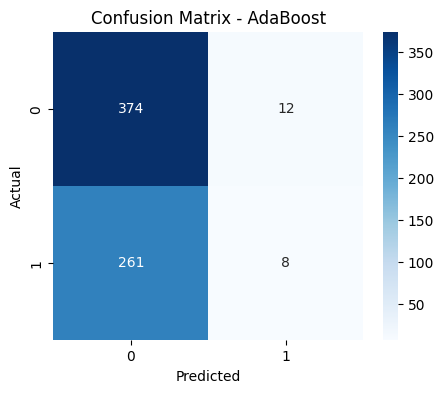


===== Naive Bayes =====
Accuracy : 0.5924
Precision: 0.5104
Recall   : 0.1822
F1 Score : 0.2685


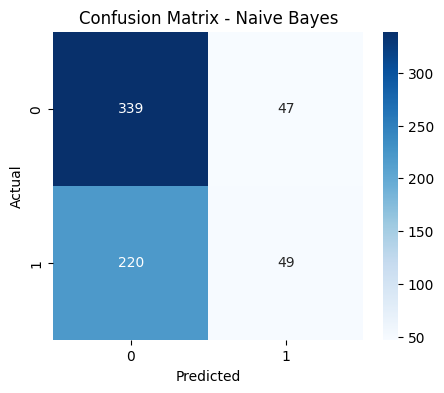


===== MLP Neural Network =====
Accuracy : 0.6412
Precision: 0.6574
Recall   : 0.2639
F1 Score : 0.3767


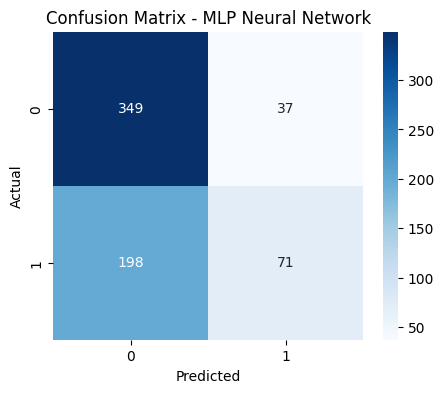

c:\Users\GEET MANTRI\anaconda3\envs\water\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



===== SVM (Linear) =====
Accuracy : 0.5893
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0


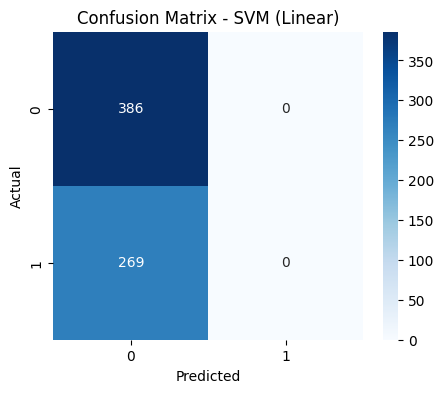



Final Comparison Table:
                 Model  Accuracy  Precision    Recall  F1 Score
3        Decision Tree  0.577099   0.484615  0.468401  0.476371
1                  KNN  0.607634   0.533708  0.353160  0.425056
8   MLP Neural Network  0.641221   0.657407  0.263941  0.376658
4        Random Forest  0.627481   0.605042  0.267658  0.371134
5    Gradient Boosting  0.619847   0.625000  0.185874  0.286533
2            SVM (RBF)  0.624427   0.657534  0.178439  0.280702
7          Naive Bayes  0.592366   0.510417  0.182156  0.268493
6             AdaBoost  0.583206   0.400000  0.029740  0.055363
0  Logistic Regression  0.590840   1.000000  0.003717  0.007407
9         SVM (Linear)  0.589313   0.000000  0.000000  0.000000


In [34]:
# Trying multiple models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "KNN": KNeighborsClassifier(),
    "SVM (RBF)": SVC(kernel='rbf'),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Naive Bayes": GaussianNB(),
    "MLP Neural Network": MLPClassifier(max_iter=500),
    "SVM (Linear)": SVC(kernel='linear')
}

results = []

# ----------------------------------------------------
# TRAIN, PREDICT & COLLECT METRICS
# ----------------------------------------------------
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, accuracy, precision, recall, f1])

    print(f"\n===== {name} =====")
    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))

    # ----------------------------
    # CONFUSION MATRIX PLOT
    # ----------------------------
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# ----------------------------------------------------
# FINAL METRICS TABLE
# ----------------------------------------------------
import pandas as pd

df_results = pd.DataFrame(
    results, 
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
)

print("\n\nFinal Comparison Table:")
print(df_results.sort_values(by="F1 Score", ascending=False))